# 01 Data Exploration

EDA on retail dataset.

   CustomerID  Recency  Frequency  MonetaryTotal  MonetaryAvg  MonetaryStd  \
0       17850      302         35        5288.63    16.950737    13.603662   
1       13047       32         18        3079.10    15.709694    11.684769   
2       12583        3         18        7187.34    28.634821    23.150132   
3       13748       96          5         948.25    33.866071    42.953119   
4       15100      330          6         635.10   105.850000   215.986263   

   MonetaryMin  MonetaryMax  TotalQuantity  AvgQuantityPerTransaction  ...  \
0       -30.60       107.25           1693                   5.426282  ...   
1       -15.00        68.00           1355                   6.913265  ...   
2       -60.84       132.80           5009                  19.956175  ...   
3         9.36       204.00            439                  15.678571  ...   
4      -131.40       350.40             58                   9.666667  ...   

                Region  LoyaltyLevel  ChurnRiskCategory  Weeke

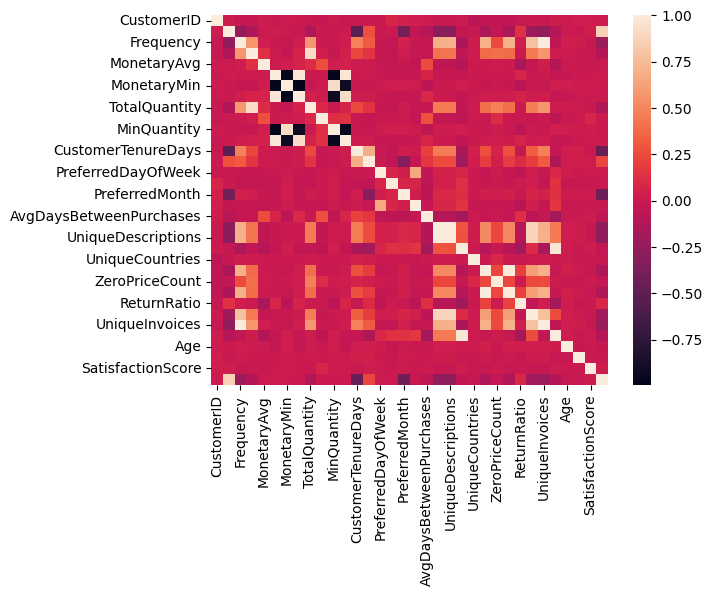

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
print(df.head())
print(df.info())
print(df.describe())
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.show()

## Missing Values & Quality

In [3]:
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

print("\n MISSING VALUES:")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])
print(f"Total missing values: {df.isnull().sum().sum()}")



DATA QUALITY ASSESSMENT

 MISSING VALUES:
                         Count  Percentage
Age                       1311       29.99
AvgDaysBetweenPurchases     79        1.81
Total missing values: 1390


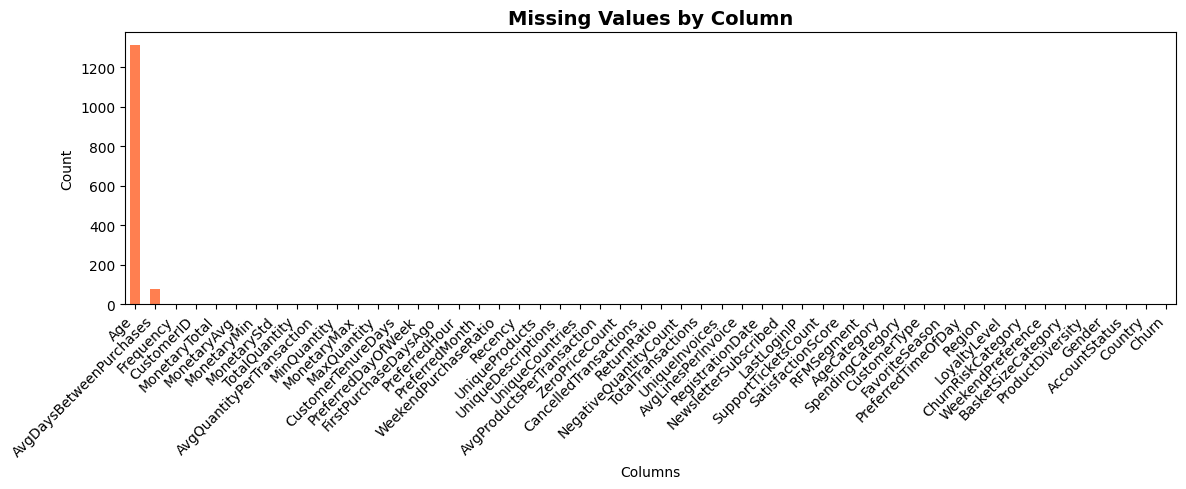

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
missing.plot(kind='bar', ax=ax, color='coral')
plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
print("\n DUPLICATE RECORDS:")
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")


 DUPLICATE RECORDS:
Duplicate rows: 0 (0.00%)


In [6]:
print("\n DATA TYPES:")
print(df.dtypes.value_counts())
print(f"\nNumerical columns: {len(df.select_dtypes(include=['number']).columns)}")
print(f"Categorical columns: {len(df.select_dtypes(include=['object']).columns)}")


 DATA TYPES:
int64      20
object     18
float64    14
Name: count, dtype: int64

Numerical columns: 34
Categorical columns: 18


In [7]:
print("\n MEMORY USAGE:")
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total memory: {memory_mb:.2f} MB")


 MEMORY USAGE:
Total memory: 5.51 MB


In [8]:
print("\n NUMERICAL STATISTICS:")
print(df.describe().T[['count', 'mean', 'std', 'min', 'max']])



 NUMERICAL STATISTICS:
                            count          mean          std            min  \
CustomerID                 4372.0  15299.677722  1722.390705   12346.000000   
Recency                    4372.0     92.047118   100.765435       1.000000   
Frequency                  4372.0      5.075480     9.338754       1.000000   
MonetaryTotal              4372.0   1898.459701  8219.345141   -4287.630000   
MonetaryAvg                4372.0     28.839013   127.323926   -4287.630000   
MonetaryStd                4372.0     88.672383  2689.001161       0.000000   
MonetaryMin                4372.0    -86.425754  2876.398935 -168469.600000   
MonetaryMax                4372.0    185.179522  2881.283699   -4287.630000   
TotalQuantity              4372.0   1122.344007  4672.790720    -303.000000   
AvgQuantityPerTransaction  4372.0     22.389288   213.257466    -144.000000   
MinQuantity                4372.0    -37.791171  1681.542061  -80995.000000   
MaxQuantity                4

In [9]:
print("\n  CATEGORICAL COLUMNS PREVIEW:")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols[:3]:  # Show first 3
    print(f"\n{col}:")
    print(df[col].value_counts().head(5))



  CATEGORICAL COLUMNS PREVIEW:

RegistrationDate:
RegistrationDate
12/10/2010    11
2010-12-21    11
01/01/2011    10
10/01/11      10
2010-12-22    10
Name: count, dtype: int64

NewsletterSubscribed:
NewsletterSubscribed
Yes    4372
Name: count, dtype: int64

LastLoginIP:
LastLoginIP
59.252.219.201    1
77.255.247.14     1
51.139.78.80      1
10.212.80.124     1
186.34.121.80     1
Name: count, dtype: int64
